In [17]:
%load_ext autoreload
%autoreload 2
%cd /home/xux/Desktop/AlphaVariant/Benchmark

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/xux/Desktop/AlphaVariant/Benchmark


# Raincloud figures — per-seed distributions (panels c & d)

Horizontal raincloud plots for the benchmark comparison figures, matching `scripts/draw_raincloud_figures.py`
(print-redesigned layout, see `figures/fig2_full_raincloud_v2.png`).

Each method row shows three layers, separated by a small gap so the IQR bar never overlaps the cloud/rain:
1. **Half-violin (cloud)** — KDE of the 30-seed distribution, drawn above the row centre
2. **Jittered scatter (rain)** — individual seed values as small dots below the row centre
3. **IQR bar + median** — a darkened, filled Q1–Q3 bar at the row centre with a white median tick;
   bar height is fixed at 0.3 mm in print regardless of method count.

Palette: AlphaVariant = vermilion; every other baseline (including ALDE/EVOLVEpro/MULTIevolve) = flat secondary gray.
Method order is fixed per task (mean rank across the group's datasets, ties broken by mean score).
Figure size is fixed in mm (80×40 mm) and margins are computed in absolute mm so the label column and
inter-panel gaps stay constant as panel count changes.

Outputs (PNG + PDF + SVG) → `figures/` and `figures/ms_oracles/`.

In [18]:
import os, sys, glob, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde

sys.path.insert(0, '.')
from utils.plot_style_utils import (
    VERMILION, SECONDARY_GRAY,
    apply_nature_rcparams, save_figure, style_axis_hbar,
)

ROOT = os.getcwd()
FIGURES_DIR = 'figures'
DISPLAY_NAMES = {'FLEXS': 'AdaLead'}

BASELINE_GRAY = SECONDARY_GRAY  # single flat color for all non-highlighted methods


def _row_color(method, cfg):
    return VERMILION if method in cfg['highlight'] else BASELINE_GRAY


def _darken(color, factor=0.55):
    """Darken a color for higher-contrast error-bar strokes."""
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)


apply_nature_rcparams({
    'axes.labelsize': 5.5, 'axes.titlesize': 5.5,
    'xtick.labelsize': 5.5, 'ytick.labelsize': 5.5,
})

np.random.seed(0)
print('Setup complete.')

Setup complete.


## Data loading helpers

### 4-site benchmark
Per-seed `max_fitness` from method result dirs (same paths as `scripts/build_median_iqr_csv.py`).

### Multi-site benchmark
Per-seed `max_fitness_norm` from `results_oracle/{dataset}/{method}/seed*.json`.

In [19]:
GMAX_4SITE = {
    '4site_GB1': 8.761966,
    '4site_PhoQ': 133.5943,
    '4site_TEV': 1.0,
    '4site_TRPB': 1.0,
}

# Path patterns for common competitors — {a} = dataset archive alias (4site_GB1, 4site_PhoQ, TRPB, ...)
COMPETITOR_PATTERNS_4SITE = {
    'Random':     'Random/results/{a}_Random/{a}/random/metrics_seed*.json',
    'GreedyWalk': 'GreedyWalk/results/{a}_GreedyWalk/{a}/greedy/metrics_seed*.json',
    'ALDE':       'ALDE/results/{a}_ALDE/{a}/onehot/metrics_seed*.json',
    'FLEXS':      'FLEXS/results/{a}_AdaLead/{a}/metrics_seed*.json',
    'AiCE':       'AiCE/results/{a}_AiCE/{a}/aice/metrics_seed*.json',
    'ftMLDE':     'ftMLDE/results/{a}_ftMLDE/{a}/ftmlde/metrics_seed*.json',
    'CLADE':      'CLADE/results/{a}_CLADE/{a}/clade/metrics_seed*.json',
    'EVOLVEpro':  'EVOLVEpro/results/{a}_EVOLVEpro/{a}/*/metrics_seed*.json',
    'MULTIevolve':'MULTIevolve/results/{a}_MULTIevolve/{a}/*/metrics_seed*.json',
    # AlphaVariant: tier-1B canonical archive (matches current summary CSV)
    'AlphaVariant': 'alphavariant/results/_archive_tier1B_canonical/{arch}/seed_*/metrics.json',
}

DS_ARCH = {
    '4site_GB1':  '4site_GB1',
    '4site_PhoQ': '4site_PhoQ',
    '4site_TEV':  '4site_TEV',
    '4site_TRPB': 'TRPB',
}

# EVOLVEpro/MULTIevolve stored their TRPB run under the full "4site_TRPB"
# archive name instead of the bare "TRPB" alias every other method uses.
ARCH_OVERRIDE = {
    ('EVOLVEpro', '4site_TRPB'): '4site_TRPB',
    ('MULTIevolve', '4site_TRPB'): '4site_TRPB',
}


def _load_4site_seeds(method, dataset, cap=30):
    arch = ARCH_OVERRIDE.get((method, dataset), DS_ARCH.get(dataset, dataset))
    pat_template = COMPETITOR_PATTERNS_4SITE.get(method)
    if pat_template is None:
        return []
    pattern = pat_template.format(a=arch, arch=arch)
    gmax = GMAX_4SITE.get(dataset, 1.0)
    vals = []
    for fp in sorted(glob.glob(pattern))[:cap]:
        try:
            d = json.load(open(fp))
            m = d.get('metrics') or d.get('final_metrics') or d
            if isinstance(m, list): m = m[-1]
            v = m.get('max_fitness')
            if v is None: continue
            if v > 1.5 and gmax != 1.0: v = v / gmax
            if 0.0 <= v <= 1.5: vals.append(float(v))
        except Exception:
            pass
    return vals


def _load_oracle_seeds(method, dataset, cap=30):
    pattern = f'results_oracle/{dataset}/{method}/seed*.json'
    vals = []
    for fp in sorted(glob.glob(pattern))[:cap]:
        try:
            d = json.load(open(fp))
            v = d.get('metrics', {}).get('max_fitness_norm')
            if v is not None and 0.0 <= v <= 1.5:
                vals.append(float(v))
        except Exception:
            pass
    return vals


def load_seed_values(method, dataset, task):
    """Return per-seed max_fitness values (normalized to [0,1]) for a method/dataset."""
    if task == '4site':
        return _load_4site_seeds(method, dataset)
    else:
        return _load_oracle_seeds(method, dataset)


print('Data loading helpers defined.')

Data loading helpers defined.


## Raincloud drawing helpers

In [20]:
def draw_raincloud_row(ax, values, y_center, color, bar_box_h, highlight=False,
                       violin_height=0.26, jitter_range=0.17):
    """Draw one horizontal raincloud row: half-violin + scatter + IQR box.

    Layout (vertical around y_center), separated by a small gap so the IQR
    bar never overlaps the cloud/rain:
      +gap+violin_height  ...  half-KDE violin (cloud) above
      y_center             ...  IQR box + median dot
      -gap-jitter_range    ...  jittered seed scatter (rain) below
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return

    dot_s = 2.5
    dot_alpha = 0.65 if highlight else 0.45
    vl_alpha = 0.50 if highlight else 0.30
    vl_lw = 0.9 if highlight else 0.5
    med_s = 12
    bar_color = _darken(color)  # darker, higher-contrast Q1-Q3 bar + median line
    med_color = bar_color if highlight else 'black'
    gap = bar_box_h / 2 + 0.035  # clearance between the bar and the violin/jitter

    # --- 1. Half-violin (KDE, upper half) ---
    if len(values) >= 4:
        try:
            kde = gaussian_kde(values)
            x_lo = max(values.min() - 0.06, 0.0)
            x_hi = min(values.max() + 0.06, 1.0)
            x_grid = np.linspace(x_lo, x_hi, 200)
            density = kde(x_grid)
            density_scaled = density / density.max() * violin_height
            ax.fill_between(x_grid, y_center + gap, y_center + gap + density_scaled,
                            color=color, alpha=vl_alpha, linewidth=0, zorder=2)
            ax.plot(x_grid, y_center + gap + density_scaled,
                    color=color, lw=vl_lw, alpha=0.85, zorder=3)
        except Exception:
            pass

    # --- 2. Jittered scatter (below centre) ---
    jitter = np.random.uniform(-jitter_range - gap, -gap, len(values))
    ax.scatter(values, y_center + jitter, s=dot_s, color=color,
               alpha=dot_alpha, linewidths=0, zorder=3)

    # --- 3. IQR box at centre ---
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    rect = Rectangle((q1, y_center - bar_box_h / 2), q3 - q1, bar_box_h,
                      facecolor=bar_color, edgecolor=bar_color,
                      linewidth=0.3, zorder=4)
    ax.add_patch(rect)
    ax.vlines(med, y_center - bar_box_h / 2, y_center + bar_box_h / 2,
              color='white', linewidth=1.1 if highlight else 0.7, zorder=5)
    ax.scatter([med], [y_center], s=med_s, color=med_color,
               edgecolors='none', linewidths=0, zorder=6)


def global_method_order(df, cfg):
    """Fixed method order: best mean rank first, mean score breaks ties."""
    datasets = cfg['dataset_order']
    main_methods = cfg['main_methods']
    sub = df[(df['dataset'].isin(datasets)) & (df['method'].isin(main_methods))].copy()
    sub['rank'] = sub.groupby('dataset')['max_fitness_median'].rank(
        ascending=False, method='average')
    agg = sub.groupby('method').agg(
        mean_rank=('rank', 'mean'),
        mean_score=('max_fitness_median', 'mean'),
    )
    agg = agg.sort_values(['mean_rank', 'mean_score'], ascending=[True, False])
    return agg.index.tolist()


print('Raincloud helpers defined.')

Raincloud helpers defined.


## Task configuration

Mirrors `scripts/draw_raincloud_figures.py` exactly — same dataset lists, method allow-lists, and axis limits.

In [21]:
TASKS = {
    '4site': {
        'csv': os.path.join(FIGURES_DIR, 'alphavariant_comparison_median_iqr.csv'),
        'outdir': FIGURES_DIR,
        'dataset_order': ['4site_GB1', '4site_PhoQ', '4site_TRPB'],
        'dataset_labels': {
            '4site_GB1': 'GB1',
            '4site_PhoQ': 'PhoQ',
            '4site_TRPB': 'TrpB',
        },
        'main_methods': {
            'Random', 'GreedyWalk', 'ALDE', 'FLEXS', 'AiCE',
            'ftMLDE', 'CLADE', 'AlphaVariant', 'MULTIevolve', 'EVOLVEpro',
        },
        'highlight': {'AlphaVariant'},
        'xlim': (0.0, 1.05),
        'xticks': np.arange(0.0, 1.01, 0.2),
        'prefix': 'main_figure_max_fitness_raincloud',
        'panel_letter': 'c',
        'label_kind': 'four-site datasets',
    },
    'multisite': {
        'csv': os.path.join(FIGURES_DIR, 'ms_oracles', 'multisite_oracle_median_iqr.csv'),
        'outdir': os.path.join(FIGURES_DIR, 'ms_oracles'),
        'dataset_order': ['ms_AAV', 'ms_CreiLOV', 'ms_PAB1'],
        'dataset_labels': {
            'ms_AAV': 'AAV',
            'ms_CreiLOV': 'CreiLOV',
            'ms_PAB1': 'PAB1',
        },
        'main_methods': {
            'Random', 'GreedyWalk', 'ALDE', 'CLADE', 'ftMLDE',
            'AdaLead', 'MULTIevolve', 'EVOLVEpro', 'AiCE', 'AlphaVariant',
        },
        'highlight': {'AlphaVariant'},
        'xlim': (0.0, 1.05),
        'xticks': np.arange(0.0, 1.01, 0.2),
        'prefix': 'main_figure_multisite_max_fitness_raincloud',
        'panel_letter': 'd',
        'label_kind': 'multi-site datasets',
    },
}

print('Task configs loaded.')

Task configs loaded.


## Main plotting function

In [22]:
def plot_raincloud_figure(task, outdir=None, save=True):
    cfg = TASKS[task]
    df = pd.read_csv(cfg['csv'])
    effective_outdir = outdir or cfg['outdir']

    # Best method (AlphaVariant) at y=n-1 -> top row; worst at y=0 -> bottom row.
    methods = global_method_order(df, cfg)[::-1]  # worst first (rank 1 = last index)
    n_methods = len(methods)
    ROW_STEP = 0.75
    y_centers = np.arange(n_methods, dtype=float) * ROW_STEP

    dataset_order = cfg['dataset_order']
    n_panels = len(dataset_order)
    MM_TO_IN = 1 / 25.4
    FIG_HEIGHT_MM = 40
    AXIS_BOTTOM, AXIS_TOP = 0.16, 0.90  # must match the subplots_adjust call below
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(80 * MM_TO_IN, FIG_HEIGHT_MM * MM_TO_IN),
        sharey=True,
    )
    axes = np.atleast_1d(axes)
    fig.patch.set_facecolor('white')

    # Q1-Q3 bar height fixed at 0.3 mm in print, converted to data units from
    # the actual axis geometry so it stays 0.3 mm regardless of n_methods.
    data_y_range = (n_methods - 1) * ROW_STEP + 0.36 + 0.30
    axis_height_mm = FIG_HEIGHT_MM * (AXIS_TOP - AXIS_BOTTOM)
    mm_per_data_unit = axis_height_mm / data_y_range
    bar_box_h = 0.3 / mm_per_data_unit

    raw_from_display = {DISPLAY_NAMES.get(m, m): m for m in methods}

    for col, (ax, dataset) in enumerate(zip(axes, dataset_order)):
        np.random.seed(col)   # reproducible jitter per column
        for row_i, method in enumerate(methods):
            vals = load_seed_values(method, dataset, task)
            if not vals:
                continue
            draw_raincloud_row(ax, vals, y_centers[row_i],
                               _row_color(method, cfg), bar_box_h,
                               highlight=(method in cfg['highlight']))

        style_axis_hbar(ax, cfg['xlim'], cfg['xticks'])
        ax.set_ylim(-0.30, (n_methods - 1) * ROW_STEP + 0.36)
        ax.set_yticks(y_centers)
        ax.set_title(cfg['dataset_labels'][dataset], pad=4, fontweight='bold', fontsize=5.5)
        ax.set_xlabel('Median max fitness', labelpad=3, fontsize=5.5)

        if col == 0:
            ax.set_yticklabels(
                [DISPLAY_NAMES.get(m, m) for m in methods], fontsize=5.5)
            for tick in ax.get_yticklabels():
                raw = raw_from_display.get(tick.get_text(), tick.get_text())
                if raw in cfg['highlight']:
                    tick.set_fontweight('bold')
                    tick.set_color(mcolors.to_hex(VERMILION))
        else:
            ax.tick_params(axis='y', labelleft=False)

    # Margins are set in absolute mm (not a fixed fraction) so the label column
    # and inter-panel gaps stay constant in size as the figure widens.
    fig_width_mm = fig.get_size_inches()[0] * 25.4
    left_mm, right_pad_mm, gap_mm = 12.4, 0.96, 2.66
    left = left_mm / fig_width_mm
    right = 1 - right_pad_mm / fig_width_mm
    axis_width_mm = ((right - left) * fig_width_mm - (n_panels - 1) * gap_mm) / n_panels
    wspace = gap_mm / axis_width_mm
    fig.subplots_adjust(left=left, right=right, bottom=AXIS_BOTTOM, top=AXIS_TOP, wspace=wspace)

    if save:
        save_figure(fig, effective_outdir, cfg['prefix'])

    plt.show()
    return fig


print('plot_raincloud_figure() defined.')

plot_raincloud_figure() defined.


## 4-site benchmark raincloud

  Saved: figures/main_figure_max_fitness_raincloud.png
  Saved: figures/main_figure_max_fitness_raincloud.pdf
  Saved: figures/main_figure_max_fitness_raincloud.svg


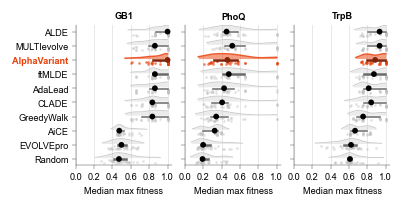

In [23]:
fig_4site = plot_raincloud_figure('4site')

## Multi-site oracle benchmark raincloud

  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_raincloud.png
  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_raincloud.pdf
  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_raincloud.svg


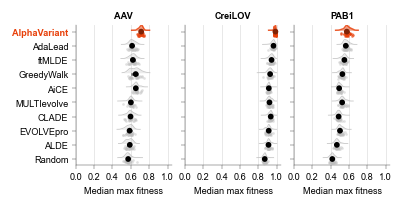

In [24]:
fig_ms = plot_raincloud_figure('multisite')